# Popularity of Different Programming Languages over Time

## 🇨🇴 Programming Language Popularity Over Time

Project 73 of 100 Challenges of Python.

Today I analyze Stack Overflow data to answer one big question:

> Which programming language has been the most popular over time?

We will:
- Load and clean data
- Work with time-series
- Pivot the dataset
- Handle missing values
- Build beautiful Matplotlib charts
- Smooth trends using rolling averages

Grab your coffee. Let’s go.

## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get latest .csv file

## 📦 Import & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Load the Dataset

Load the Stack Overflow dataset and rename the columns for clarity.

Columns:
- DATE
- TAG
- POSTS

In [2]:
df = pd.read_csv('QueryResults.csv', names=['DATE', 'TAG', 'POSTS'], header=0)

df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,82
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


## 🔎 Basic Data Exploration

Let’s inspect:
- First rows
- Last rows
- Shape
- Info

In [3]:
df.tail()

,DATE,TAG,POSTS
2910,2026-01-01 00:00:00,php,49
2911,2026-01-01 00:00:00,python,372
2912,2026-01-01 00:00:00,r,69
2913,2026-01-01 00:00:00,ruby,7
2914,2026-01-01 00:00:00,swift,63


In [4]:
df.shape

(2915, 3)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   DATE    2915 non-null   str  
 1   TAG     2915 non-null   str  
 2   POSTS   2915 non-null   int64
dtypes: int64(1), str(2)
memory usage: 68.4 KB


## 🏆 Which Language Has the Most Posts?

Group by TAG and sum POSTS to see total popularity.

In [6]:
total_posts = df.groupby('TAG').agg({'POSTS': 'sum'})

total_posts.sort_values('POSTS', ascending=False)

,POSTS
TAG,
javascript,2524897
python,2207238
java,1916658
c#,1622973
php,1463703
c++,814576
r,510571
c,408155
swift,336173


## ⏳ Convert DATE to Datetime

Right now DATE is a string.
We convert it so Pandas treats it as real time data.

In [7]:
df['DATE'] = pd.to_datetime(df['DATE'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    2915 non-null   datetime64[us]
 1   TAG     2915 non-null   str           
 2   POSTS   2915 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 68.4 KB


## 🔄 Pivot the DataFrame

Now reshape the dataset so:

- Rows → DATE
- Columns → Programming Languages
- Values → POSTS

This makes plotting much easier.

In [8]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')

reshaped_df.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01,28.0,320.0,1637.0,749.0,104.0,NaN,1121.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,720.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01,16.0,257.0,1728.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN


## 🧼 Handle Missing Values

Some languages didn’t exist in early years.

Pivot creates NaN values.

Then replace them with 0.

In [9]:
reshaped_df.fillna(0, inplace=True)

reshaped_df.isna().values.any()

np.False_

## 🌎 Plot All Languages

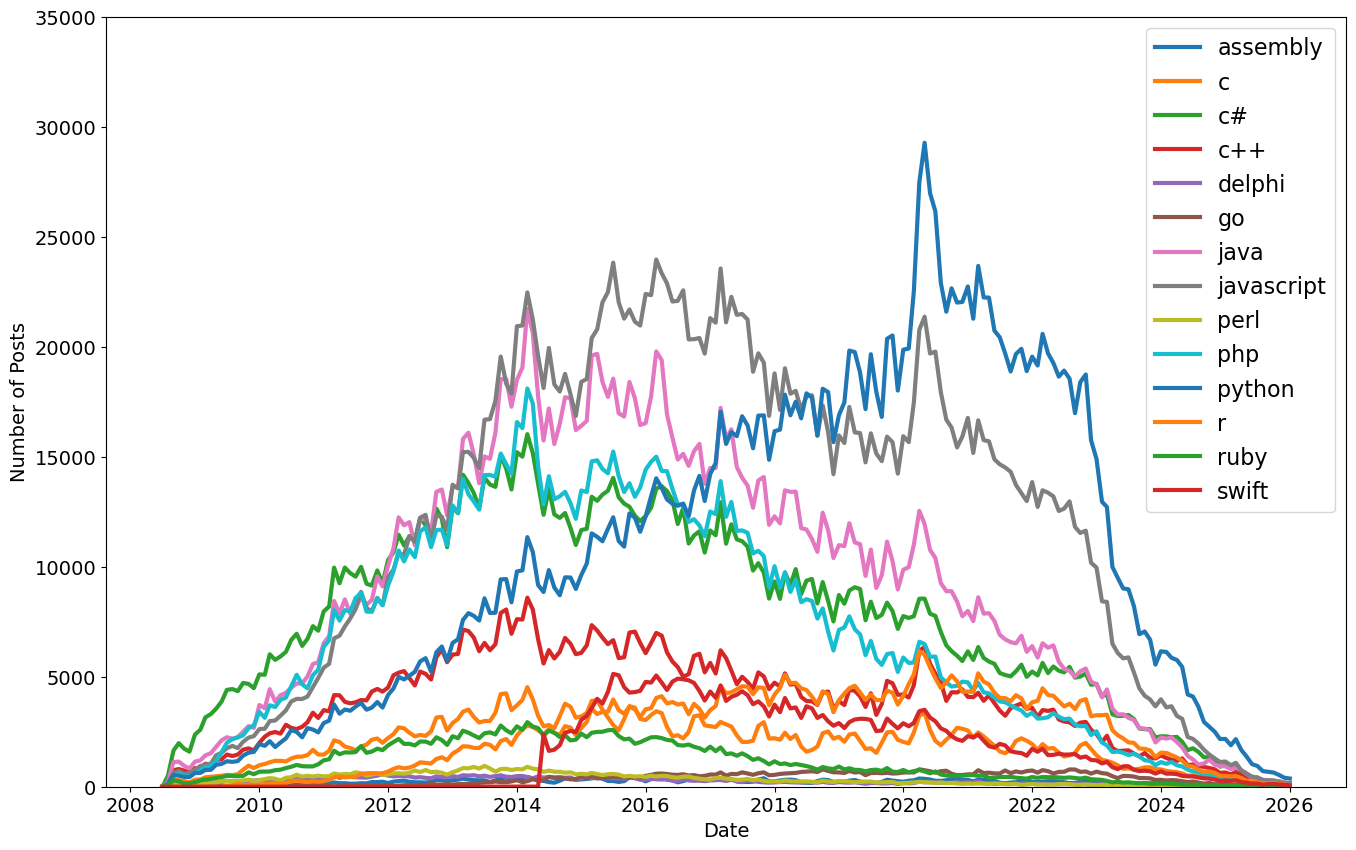

In [10]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column], 
             linewidth=3, label=reshaped_df[column].name)
 
plt.legend(fontsize=16)

## 📊 Smooth the Trends (Rolling Mean)

Time-series data is noisy.

Compute a 6-month rolling average to make trends clearer.

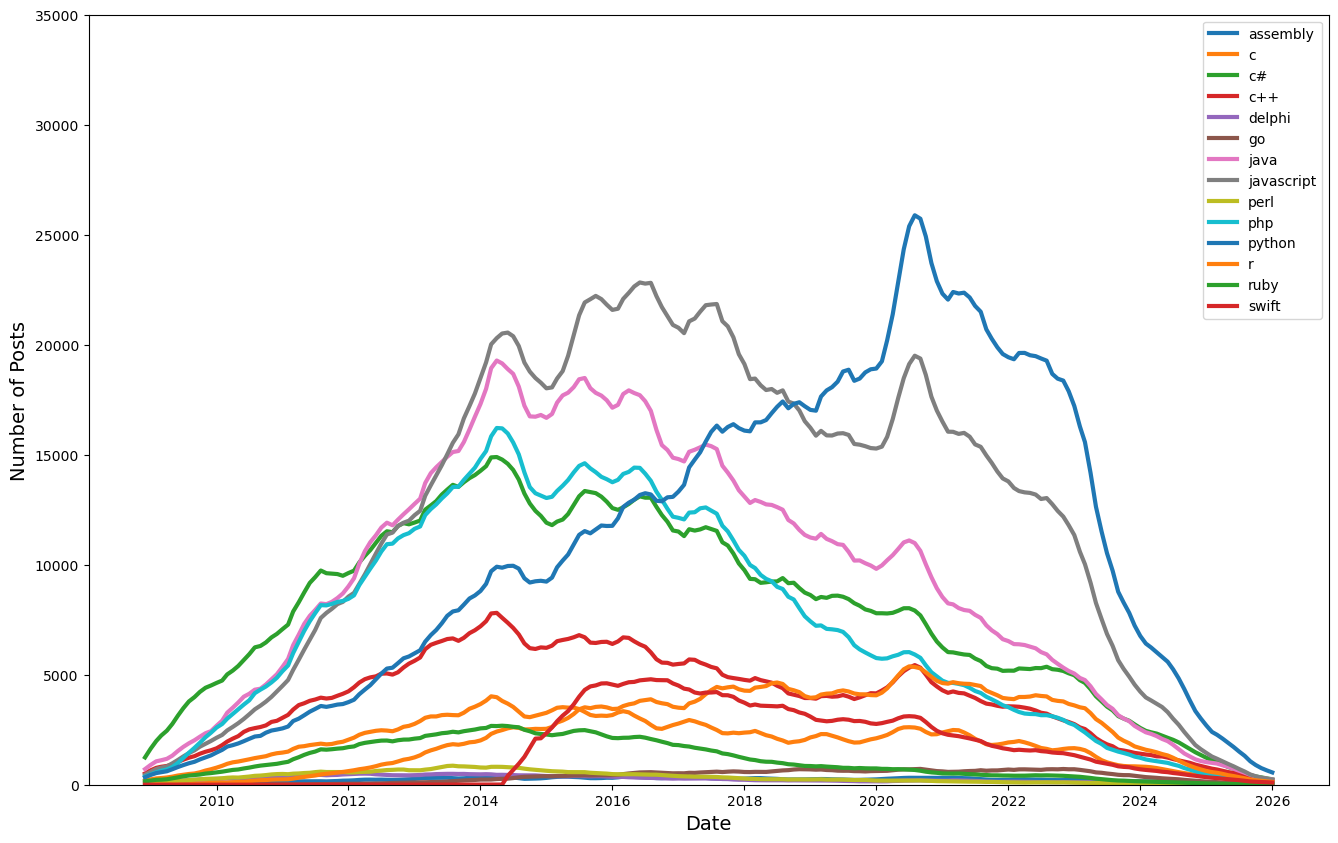

In [11]:
roll_df = reshaped_df.rolling(window=6).mean()

plt.figure(figsize=(16,10))

for column in roll_df.columns:
    plt.plot(
        roll_df.index,
        roll_df[column],
        linewidth=3,
        label=column
    )

plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)

plt.legend(fontsize=10)

plt.show()

## 📊 Individual Language View (Grid Layout)

Instead of plotting all languages in a single chart,  
let's now create a grid of subplots.

Each programming language gets its own mini-chart.

This makes it easier to observe individual trends without visual clutter.

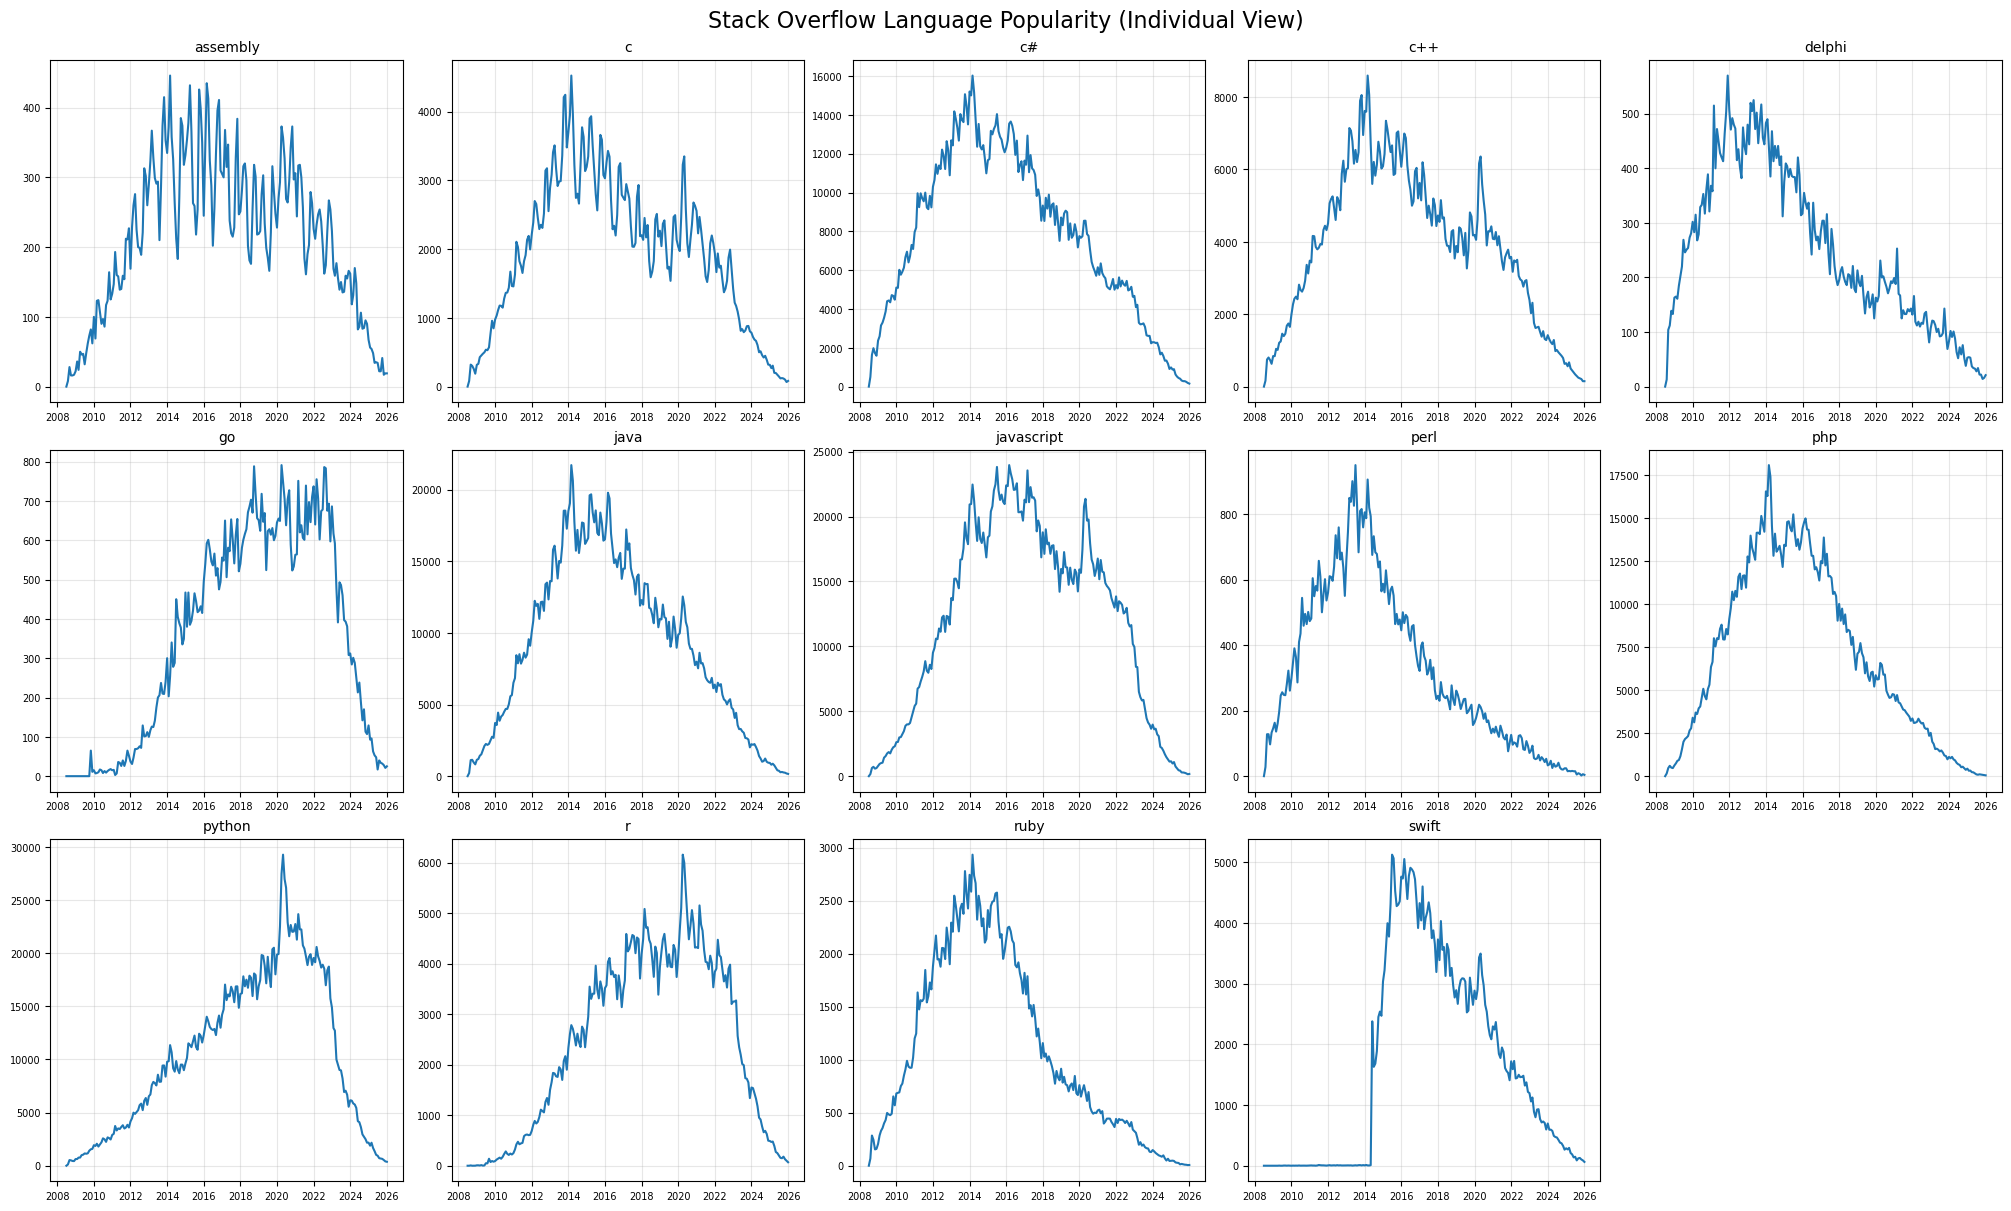

In [12]:
# Convert columns to list
column_list = reshaped_df.columns.to_list()

# Define grid parameters
n_cols = 5
n_rows = 3

# Create grid
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 12), layout="constrained")

for i, col_name in enumerate(column_list):
    ax = axs.flat[i]
    
    ax.plot(
        reshaped_df.index,
        reshaped_df[col_name],
        linewidth=1.5
    )
    
    ax.set_title(f'{col_name}', fontsize=10)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(column_list), n_rows * n_cols):
    axs.flat[j].axis('off')

fig.suptitle("Stack Overflow Language Popularity (Individual View)", fontsize=16)

plt.show()

## 🇨🇴 Final Thoughts

Today I:

- Used groupby() to measure popularity
- Converted strings to datetime
- Pivoted our dataset
- Replaced NaN values
- Built multi-line charts
- Smoothed time-series data

And the winner?

🐍 Python dominates Stack Overflow over time.